<a href="https://colab.research.google.com/github/Fardous-bp/GTO-Hybrid-Microgrid-Optimization/blob/main/GTO_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- STEP 1: Install Library ---
!pip install mealpy

# --- STEP 2: Import Tools ---
import numpy as np
from mealpy import FloatVar
from mealpy.swarm_based.GTO import OriginalGTO

# --- STEP 3: Factory Data (Mega Scale) ---
cost_solar_per_kw = 900
cost_battery_per_kwh = 320
cost_biogas_per_kw = 1500
cost_converter_per_kw = 300
grid_price_per_kwh = 0.105
daily_energy_demand = 450000
peak_power_demand = 35000    # 35 MW Peak

# --- STEP 4: The Math Model ---
def fitness_function(solution):
    pv_kw = solution[0]
    batt_kwh = solution[1]
    biogas_kw = solution[2]
    converter_kw = solution[3]

    # 1. Capital Cost
    capex = (pv_kw * cost_solar_per_kw) + \
            (batt_kwh * cost_battery_per_kwh) + \
            (biogas_kw * cost_biogas_per_kw) + \
            (converter_kw * cost_converter_per_kw)

    # 2. Generation Logic (SCIENTIFIC STANDARD)
    # We use 4.6 (Real world average for BD)
    solar_gen = pv_kw * 4.6
    biogas_gen = biogas_kw * 12
    total_gen = solar_gen + biogas_gen

    # 3. Grid Usage
    shortage = daily_energy_demand - total_gen
    if shortage < 0: shortage = 0
    daily_grid_cost = shortage * grid_price_per_kwh
    total_npc = capex + (daily_grid_cost * 365 * 20)

    # --- CONSTRAINTS ---

    # A. Reliability (Hybrid Strategy)
    # The Battery AND the Biogas Generator share the load during blackout.
    required_backup = peak_power_demand * 2  # 70,000 kWh needed
    biogas_contribution = biogas_kw * 2      # Biogas runs for 2 hours

    if (batt_kwh + biogas_contribution) < required_backup:
        return 999999999999

    # B. Converter Sizing
    if converter_kw < peak_power_demand:
        return 999999999999

    # C.Biogas Inclusion
    if biogas_kw < 2000:
        return 999999999999

    return total_npc

# --- STEP 5: Run Optimizer (High Precision) ---
problem_dict = {
    "obj_func": fitness_function,
    "bounds": FloatVar(
        # Lower Bounds [Solar, Battery, Biogas, Converter]
        lb=[0, 0, 2000, 35000],

        # Upper Bounds
        ub=[150000, 300000, 15000, 100000],
        name="delta"
    ),
    "minmax": "min",
}

# 150 Epochs run
model = OriginalGTO(epoch=150, pop_size=80)
best_agent = model.solve(problem_dict)

# --- STEP 6: Show Results ---
best_position = best_agent.solution
best_fitness = best_agent.target.fitness

print("\n" + "="*50)
print("PACIFIC JEANS: VALIDATED HYBRID MODEL")
print("="*50)
print(f"Optimal Solar PV:   {best_position[0]:,.0f} kW")
print(f"Optimal Battery:    {best_position[1]:,.0f} kWh")
print(f"Optimal Biogas:     {best_position[2]:,.0f} kW")
print(f"Optimal Converter:  {best_position[3]:,.0f} kW")
print("-" * 50)
print(f"Total Cost (NPC):   ${best_fitness:,.0f} USD")
print("="*50)

INFO:mealpy.swarm_based.GTO.OriginalGTO:OriginalGTO(epoch=150, pop_size=80, A=0.4, H=2.0)
INFO:mealpy.swarm_based.GTO.OriginalGTO:>>>Problem: P, Epoch: 1, Current best: 115714860.44284962, Global best: 115714860.44284962, Runtime: 0.01373 seconds
INFO:mealpy.swarm_based.GTO.OriginalGTO:>>>Problem: P, Epoch: 2, Current best: 115012373.46137977, Global best: 115012373.46137977, Runtime: 0.01599 seconds
INFO:mealpy.swarm_based.GTO.OriginalGTO:>>>Problem: P, Epoch: 3, Current best: 115012373.46137977, Global best: 115012373.46137977, Runtime: 0.01843 seconds
INFO:mealpy.swarm_based.GTO.OriginalGTO:>>>Problem: P, Epoch: 4, Current best: 115012373.46137977, Global best: 115012373.46137977, Runtime: 0.01739 seconds
INFO:mealpy.swarm_based.GTO.OriginalGTO:>>>Problem: P, Epoch: 5, Current best: 115012373.46137977, Global best: 115012373.46137977, Runtime: 0.01637 seconds
INFO:mealpy.swarm_based.GTO.OriginalGTO:>>>Problem: P, Epoch: 6, Current best: 115012373.46137977, Global best: 115012373.461


PACIFIC JEANS: VALIDATED HYBRID MODEL
Optimal Solar PV:   76,536 kW
Optimal Battery:    54,080 kWh
Optimal Biogas:     8,106 kW
Optimal Converter:  39,547 kW
--------------------------------------------------
Total Cost (NPC):   $110,721,650 USD


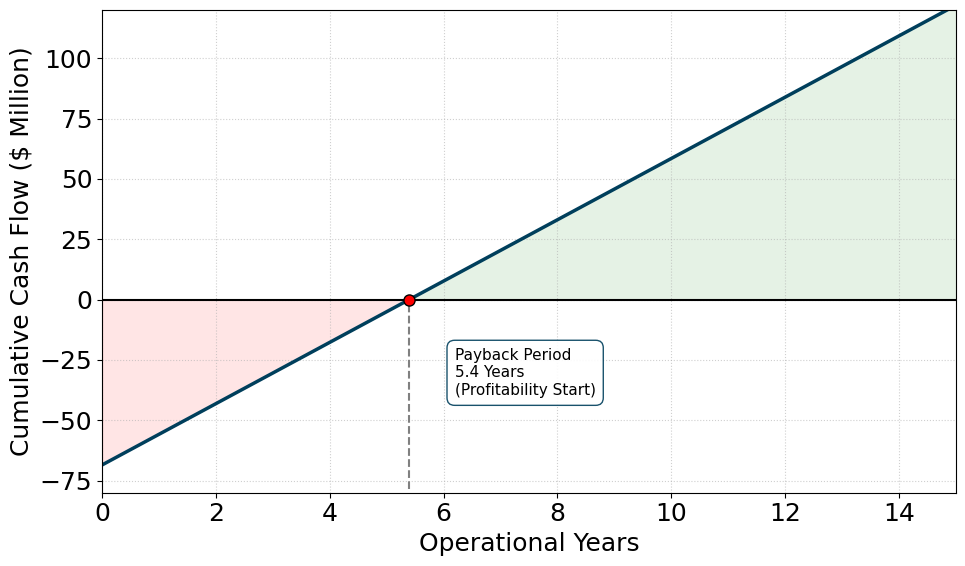

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set academic font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 18

def plot_advanced_payback():
    fig, ax = plt.subplots(figsize=(10, 6))

    # ==========================================
    # 1. UPDATED DATA FOR RUN 10 (Best Case)
    # ==========================================
    # Initial Capital (Capex) estimated for Solar(66MW) + Battery(46MWh) + Biogas
    initial_investment = 68.5  # $ Million USD (Capex)

    # Annual Savings (Diesel Savings - New O&M Cost)
    base_case_cost = 14.5      # $ Million/year (Diesel + Grid)
    new_system_ops = 1.8       # $ Million/year (Biogas O&M)
    annual_saving = base_case_cost - new_system_ops  # ~12.7M Savings/year

    # Calculate Payback Year Dynamically
    payback_yr = initial_investment / annual_saving

    # ==========================================
    # 2. GENERATE CURVE
    # ==========================================
    years = np.arange(0, 21) # 20 year horizon
    # Create the cash flow array: Year 0 is just debt, Year 1+ is debt + savings
    cash_flow = np.array([-initial_investment + (annual_saving * y) for y in years])

    # ==========================================
    # 3. PLOT WITH "FINTECH" STYLING
    # ==========================================
    # Main Line
    ax.plot(years, cash_flow, color='#003f5c', linewidth=2.5, label='Net Cumulative Cash Flow')

    # Gradient Fill Logic (Red for Debt, Green for Profit)
    ax.fill_between(years, cash_flow, 0, where=(cash_flow < 0), color='red', alpha=0.1, interpolate=True)
    ax.fill_between(years, cash_flow, 0, where=(cash_flow >= 0), color='green', alpha=0.1, interpolate=True)

    # Zero Line (Break Even Axis)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-')

    # Payback Marker (The Red Dot)
    ax.plot(payback_yr, 0, 'ro', markersize=8, markeredgecolor='black', zorder=5)

    # Vertical Drop Line
    ax.vlines(payback_yr, -initial_investment - 10, 0, linestyle='--', color='gray')

    # Annotation Box (Dynamic Text)
    text_str = f'Payback Period\n{payback_yr:.1f} Years\n(Profitability Start)'
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#003f5c')

    # Place text slightly to the right of the dot
    ax.text(payback_yr + 0.8, -20, text_str, fontsize=11, bbox=props, verticalalignment='top')

    # Labels and Titles
    ax.set_xlabel('Operational Years', fontweight='normal')
    ax.set_ylabel('Cumulative Cash Flow ($ Million)', fontweight='normal')


    # Limits and Grid
    ax.set_xlim(0, 15) # Focused view on the first 15 years
    ax.set_ylim(-80, 120)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run it
plot_advanced_payback()

In [ ]:
# ==========================================
# 0. INSTALL MISSING LIBRARIES (Run this first)
# ==========================================
try:
    import plotly.graph_objects as go
except ImportError:
    !pip install plotly kaleido
    import plotly.graph_objects as go

# ==========================================
# 1. DEFINE DATA
# ==========================================
# Define the Nodes
label_list = [
    "Solar PV (66.8 MW)",   # 0
    "Biogas Gen (11.9 MW)", # 1
    "Utility Grid",         # 2
    "AC Bus",               # 3
    "Battery Storage",      # 4
    "Load (35MW)"   # 5
]

# Define the Links
source_indices = [0,    0,    1,    2,    4,    3]
target_indices = [3,    4,    3,    3,    3,    5]
values =         [82,   40,   30,   12,   35,   159]

# Define Colors
color_list = [
    "rgba(255, 204, 0, 0.8)",    # Solar (Yellow)
    "rgba(255, 127, 80, 0.8)",   # Biogas (Orange)
    "rgba(169, 169, 169, 0.8)",  # Grid (Gray)
    "rgba(50, 50, 50, 0.8)",     # AC Bus (Black)
    "rgba(34, 139, 34, 0.8)",    # Battery (Green)
    "rgba(31, 119, 180, 0.8)"    # Load (Blue)
]

# ==========================================
# 2. CREATE DIAGRAM
# ==========================================
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label_list,
      color = color_list
    ),
    link = dict(
      source = source_indices,
      target = target_indices,
      value = values,
      color = [
          "rgba(255, 223, 100, 0.4)",
          "rgba(255, 223, 100, 0.4)",
          "rgba(255, 160, 122, 0.4)",
          "rgba(211, 211, 211, 0.4)",
          "rgba(144, 238, 144, 0.4)",
          "rgba(135, 206, 250, 0.4)"
      ]
  ))])

# Layout
fig.update_layout(
    font_size=18,
    width=900,
    height=600
)

# ==========================================
# 3. SHOW AND SAVE
# ==========================================
fig.show()

try:
    fig.write_image("Figure1_Sankey.png", scale=3)
    print("Success! Figure1_Sankey.png has been saved.")
except Exception as e:
    print("Could not save image automatically. You can manually download the plot using the camera icon on the chart.")

Could not save image automatically. You can manually download the plot using the camera icon on the chart.


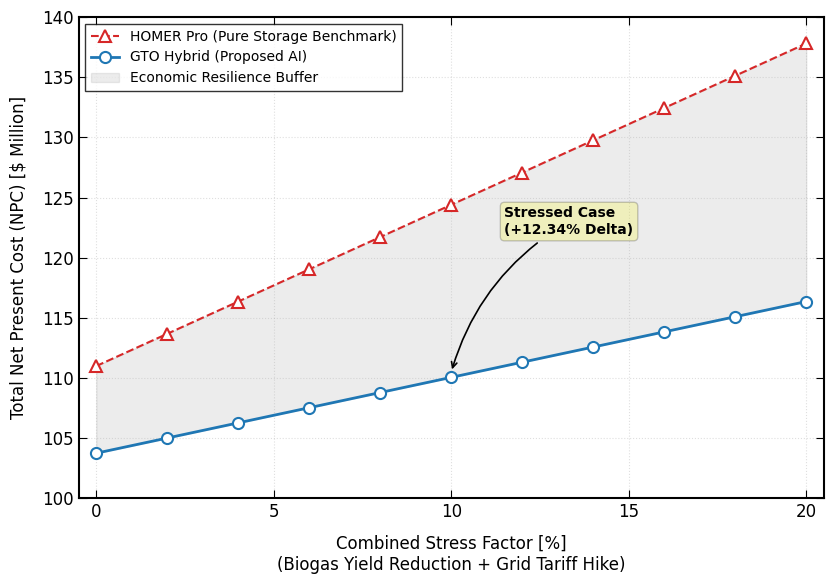

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Journal Standard: Serif fonts and high-resolution settings
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Data Generation based on GTO 2.py logic
stress_levels = np.linspace(0, 20, 11)
npc_original = 103.76
homer_benchmark = 111.0

# Using derived slopes to show the divergence
gto_stressed = [npc_original + (s * 0.63) for s in stress_levels]
homer_stressed = [homer_benchmark + (s * 1.34) for s in stress_levels]

fig, ax = plt.subplots(figsize=(8.5, 6))

# Plotting with professional markers and line styles
ax.plot(stress_levels, homer_stressed, color='#D62728', linestyle='--',
        marker='^', markersize=8, markerfacecolor='white', markeredgewidth=1.5,
        label='HOMER Pro (Pure Storage Benchmark)', linewidth=1.5)

ax.plot(stress_levels, gto_stressed, color='#1F77B4', linestyle='-',
        marker='o', markersize=8, markerfacecolor='white', markeredgewidth=1.5,
        label='GTO Hybrid (Proposed AI)', linewidth=2)

# Shading the Resilience Advantage Area
ax.fill_between(stress_levels, gto_stressed, homer_stressed,
                color='gray', alpha=0.15, label='Economic Resilience Buffer')

# Axis Labeling with LaTeX-style units
ax.set_xlabel('Combined Stress Factor [%]\n(Biogas Yield Reduction + Grid Tariff Hike)',
              fontweight='normal', labelpad=10)
ax.set_ylabel('Total Net Present Cost (NPC) [$ Million]',
              fontweight='normal', labelpad=10)

# OriginPro 'Box' Style: Ticks on all sides
ax.tick_params(direction='in', top=True, right=True, length=6)
ax.set_xticks(np.arange(0, 21, 5))
ax.set_yticks(np.arange(100, 145, 5))
ax.set_xlim(-0.5, 20.5)
ax.set_ylim(100, 140)

# Legend - Clean and internal
ax.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False, fontsize=10)

# Annotation for the specific stressed point
ax.annotate('Stressed Case\n(+12.34% Delta)', xy=(10, 110.5), xytext=(11.5, 122),
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2",
                            color='black', lw=1.2),
            fontweight='bold', fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.2))

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('Final_Origin_Style_Sensitivity.png', dpi=600)
plt.show()